In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

benchmark = pd.read_csv("../data/processed/benchmark_indices_cleaned.csv")

In [4]:
print(nav.head())

print(performance.head())

print(benchmark.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct  

In [5]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [6]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [7]:
nav["date"] = pd.to_datetime(nav["date"])

In [8]:
nav = nav.sort_values(["amfi_code", "date"])

In [9]:
def calculate_cagr(nav_df, years):

    end_date = nav_df["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    start_nav = (
        nav_df[nav_df["date"] >= start_date]
        .groupby("amfi_code")
        .first()["nav"]
    )

    end_nav = (
        nav_df.groupby("amfi_code")
        .last()["nav"]
    )

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    return cagr.reset_index(name=f"CAGR_{years}Y")

In [10]:
cagr_1 = calculate_cagr(nav, 1)
cagr_3 = calculate_cagr(nav, 3)
cagr_5 = calculate_cagr(nav, 5)

In [11]:
performance.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [12]:
cagr_table = (
    performance[["amfi_code", "scheme_name"]]
    .merge(cagr_1, on="amfi_code", how="left")
    .merge(cagr_3, on="amfi_code", how="left")
    .merge(cagr_5, on="amfi_code", how="left")
)

In [13]:
cagr_table = cagr_table.round(2)

cagr_table.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,119551,SBI Bluechip Fund - Regular Plan - Growth,60.44,30.46,22.38
1,119552,SBI Bluechip Fund - Direct Plan - Growth,5.71,16.27,18.71
2,119598,SBI Small Cap Fund - Regular Plan - Growth,82.78,26.67,28.03
3,119599,SBI Small Cap Fund - Direct Plan - Growth,13.95,-1.34,1.81
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.52,5.84,5.16


In [14]:
cagr_table = cagr_table.sort_values(
    by="CAGR_3Y",
    ascending=False
)

cagr_table.head(10)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
26,119094,Axis Midcap Fund - Regular - Growth,22.26,35.11,24.45
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.36,34.00,26.80
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,13.06,32.49,20.23
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,26.07
12,120505,ICICI Pru Midcap Fund - Regular - Growth,29.60,31.78,28.38
0,119551,SBI Bluechip Fund - Regular Plan - Growth,60.44,30.46,22.38
22,120843,Kotak Flexicap Fund - Regular - Growth,26.66,29.58,26.74
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,39.75,29.18,27.63
28,101206,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97,20.44
39,149324,DSP Small Cap Fund - Regular - Growth,65.14,27.00,27.92


In [15]:
cagr_table.to_csv("../outputs/cagr_comparison.csv", index=False)

## CAGR Analysis

CAGR was calculated using historical NAV data over 1-year, 3-year, and 5-year periods.

Funds with consistently higher CAGR values indicate stronger long-term wealth creation potential. Comparing different investment horizons helps identify schemes with stable long-term performance rather than short-term gains.

In [16]:
RISK_FREE_RATE = 0.065
DAILY_RF = RISK_FREE_RATE / 252

In [18]:
nav = nav.sort_values(["amfi_code", "date"])

In [19]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [20]:
daily_returns = nav.dropna(subset=["daily_return"])

In [21]:
daily_returns.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [22]:
sharpe = (
    daily_returns.groupby("amfi_code")["daily_return"]
    .agg(["mean", "std"])
    .reset_index()
)

sharpe.head()

,amfi_code,mean,std
0,100016,0.000142,0.009164
1,100025,0.000170,0.002460
2,100033,0.001080,0.011929
3,101206,0.000852,0.009177
4,101207,0.000424,0.016251


In [23]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [25]:
RISK_FREE_RATE = 0.065
DAILY_RF = RISK_FREE_RATE / 252

In [26]:
sharpe["Sharpe_Ratio"] = (
    (sharpe["mean"] - DAILY_RF)
    / sharpe["std"]
) * np.sqrt(252)

sharpe.head()

,amfi_code,mean,std,Sharpe_Ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [27]:
sharpe = sharpe.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sharpe.head()

,amfi_code,mean,std,Sharpe_Ratio,scheme_name
0,100016,0.000142,0.009164,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.000170,0.002460,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.000424,0.016251,0.162661,ABSL Small Cap Fund - Regular - Growth


In [28]:
sharpe["Sharpe_Rank"] = sharpe["Sharpe_Ratio"].rank(
    ascending=False,
    method="dense"
)

sharpe = sharpe.sort_values("Sharpe_Rank")

sharpe.head(10)

,amfi_code,mean,std,Sharpe_Ratio,scheme_name,Sharpe_Rank
34,148567,0.001074,0.008941,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,1.0
30,120843,0.001082,0.010008,1.306744,Kotak Flexicap Fund - Regular - Growth,2.0
36,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,3.0
19,119551,0.000917,0.008656,1.208267,SBI Bluechip Fund - Regular Plan - Growth,4.0
25,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth,5.0
38,149323,0.001055,0.011179,1.132122,DSP Midcap Fund - Regular - Growth,6.0
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7.0
9,118632,0.000865,0.008913,1.081659,Nippon India Large Cap Fund - Regular - Growth,8.0
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth,9.0
24,120504,0.000843,0.009048,1.026524,ICICI Pru Bluechip Fund - Direct - Growth,10.0


In [29]:
sharpe.to_csv("../outputs/sharpe_ratio.csv", index=False)

## Sharpe Ratio Analysis

The Sharpe Ratio evaluates the risk-adjusted performance of each mutual fund by comparing excess returns with total volatility. Funds with higher Sharpe Ratios generated better returns for each unit of risk taken.

In [30]:
downside_returns = daily_returns.copy()

downside_returns["downside_return"] = downside_returns["daily_return"].where(
    downside_returns["daily_return"] < 0,
    0
)

downside_returns.head()

,amfi_code,date,nav,daily_return,downside_return
1,100016,2022-01-04,515.0971,-0.010306,-0.010306
2,100016,2022-01-05,521.7239,0.012865,0.000000
3,100016,2022-01-06,515.7880,-0.011377,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,-0.001210
5,100016,2022-01-10,510.7136,-0.008639,-0.008639


In [31]:
sortino = (
    downside_returns.groupby("amfi_code")
    .agg(
        mean_return=("daily_return", "mean"),
        downside_std=("downside_return", "std")
    )
    .reset_index()
)

sortino.head()

,amfi_code,mean_return,downside_std
0,100016,0.000142,0.005163
1,100025,0.000170,0.001382
2,100033,0.001080,0.006632
3,101206,0.000852,0.004989
4,101207,0.000424,0.009256


In [32]:
sortino["Sortino_Ratio"] = (
    (sortino["mean_return"] - DAILY_RF)
    / sortino["downside_std"]
) * np.sqrt(252)

sortino.head()

,amfi_code,mean_return,downside_std,Sortino_Ratio
0,100016,0.000142,0.005163,-0.357702
1,100025,0.000170,0.001382,-1.009643
2,100033,0.001080,0.006632,1.967316
3,101206,0.000852,0.004989,1.889576
4,101207,0.000424,0.009256,0.285576


In [33]:
sortino = sortino.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sortino.head()

,amfi_code,mean_return,downside_std,Sortino_Ratio,scheme_name
0,100016,0.000142,0.005163,-0.357702,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.000170,0.001382,-1.009643,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.001080,0.006632,1.967316,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.000852,0.004989,1.889576,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.000424,0.009256,0.285576,ABSL Small Cap Fund - Regular - Growth


In [34]:
sortino["Sortino_Rank"] = sortino["Sortino_Ratio"].rank(
    ascending=False,
    method="dense"
)

sortino = sortino.sort_values("Sortino_Rank")

sortino.head(10)

,amfi_code,mean_return,downside_std,Sortino_Ratio,scheme_name,Sortino_Rank
34,148567,0.001074,0.004962,2.609850,Mirae Asset Large Cap Fund - Regular - Growth,1.0
30,120843,0.001082,0.005308,2.463887,Kotak Flexicap Fund - Regular - Growth,2.0
36,148569,0.001124,0.006035,2.278106,Mirae Asset Tax Saver Fund - Regular - Growth,3.0
19,119551,0.000917,0.004662,2.243325,SBI Bluechip Fund - Regular Plan - Growth,4.0
25,120505,0.001161,0.006644,2.158384,ICICI Pru Midcap Fund - Regular - Growth,5.0
38,149323,0.001055,0.006291,2.011887,DSP Midcap Fund - Regular - Growth,6.0
2,100033,0.001080,0.006632,1.967316,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7.0
9,118632,0.000865,0.004914,1.961986,Nippon India Large Cap Fund - Regular - Growth,8.0
3,101206,0.000852,0.004989,1.889576,ABSL Frontline Equity Fund - Regular - Growth,9.0
24,120504,0.000843,0.004947,1.877411,ICICI Pru Bluechip Fund - Direct - Growth,10.0


In [35]:
sortino.to_csv("../outputs/sortino_ratio.csv", index=False)

## Sortino Ratio Analysis

The Sortino Ratio evaluates risk-adjusted performance by considering only downside volatility. Funds with higher Sortino Ratios delivered stronger returns while minimizing negative return fluctuations, making them attractive for risk-conscious investors.

In [38]:
benchmark.head()


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [37]:
benchmark.columns.tolist()

['date', 'index_name', 'close_value']

In [39]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [40]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100 = nifty100.dropna()

nifty100.head()

,date,index_name,close_value,benchmark_return
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351


In [43]:
nifty100["date"] = pd.to_datetime(nifty100["date"])

In [45]:
print(daily_returns["date"].dtype)
print(nifty100["date"].dtype)

datetime64[ns]
datetime64[ns]


In [44]:
merged = daily_returns.merge(
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-04,515.0971,-0.010306,-0.013540
1,100016,2022-01-05,521.7239,0.012865,0.004003
2,100016,2022-01-06,515.7880,-0.011377,-0.002935
3,100016,2022-01-07,515.1639,-0.001210,0.006150
4,100016,2022-01-10,510.7136,-0.008639,-0.008351


In [46]:
from scipy.stats import linregress

results = []

for fund in merged["amfi_code"].unique():

    temp = merged[
        merged["amfi_code"] == fund
    ]

    slope, intercept, r_value, p_value, std_err = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )

    results.append({
        "amfi_code": fund,
        "Alpha": intercept * 252,
        "Beta": slope
    })

alpha_beta = pd.DataFrame(results)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [47]:
alpha_beta = alpha_beta.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta.head()

,amfi_code,Alpha,Beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [48]:
alpha_beta = alpha_beta.round(4)

alpha_beta.head()

,amfi_code,Alpha,Beta,scheme_name
0,100016,0.0375,-0.0583,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.0428,0.0012,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.2720,0.0051,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.2140,0.0211,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.1090,-0.0653,ABSL Small Cap Fund - Regular - Growth


In [51]:
alpha_beta.to_csv("../outputs/alpha_beta.csv", index=False)

## Alpha & Beta Analysis

Beta measures the sensitivity of a mutual fund to benchmark market movements. A Beta greater than 1 indicates higher volatility than the benchmark, while a Beta below 1 indicates lower volatility.

Alpha measures excess return over the benchmark after adjusting for market risk. Positive Alpha indicates the fund outperformed the benchmark on a risk-adjusted basis.

In [53]:
nav["running_max"] = (
    nav.groupby("amfi_code")["nav"]
    .cummax()
)

In [54]:
nav["drawdown"] = (
    nav["nav"] / nav["running_max"]
) - 1

nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [55]:
max_drawdown = (
    nav.groupby("amfi_code")["drawdown"]
    .min()
    .reset_index()
)

max_drawdown.head()

,amfi_code,drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [56]:
worst_dates = (
    nav.loc[
        nav.groupby("amfi_code")["drawdown"].idxmin(),
        ["amfi_code", "date", "drawdown"]
    ]
)

worst_dates.head()

,amfi_code,date,drawdown
183,100016,2022-09-15,-0.247344
1559,100025,2023-07-28,-0.043083
2393,100033,2022-05-12,-0.162172
3842,101206,2023-07-05,-0.112916
5735,101207,2026-05-11,-0.354469


In [57]:
max_drawdown = max_drawdown.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

max_drawdown = max_drawdown.merge(
    worst_dates[["amfi_code", "date"]],
    on="amfi_code",
    how="left"
)

max_drawdown.head()

,amfi_code,drawdown,scheme_name,date
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth,2022-09-15
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth,2023-07-28
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,2022-05-12
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth,2023-07-05
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth,2026-05-11


In [58]:
max_drawdown.rename(
    columns={
        "drawdown": "Maximum_Drawdown",
        "date": "Worst_Drawdown_Date"
    },
    inplace=True
)

max_drawdown.head()

,amfi_code,Maximum_Drawdown,scheme_name,Worst_Drawdown_Date
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth,2022-09-15
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth,2023-07-28
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,2022-05-12
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth,2023-07-05
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth,2026-05-11


In [59]:
max_drawdown.to_csv(
    "../outputs/max_drawdown.csv",
    index=False
)

## Maximum Drawdown Analysis

Maximum Drawdown measures the largest percentage decline from a fund's historical peak NAV.

Lower drawdowns indicate better downside protection during market corrections, while larger drawdowns highlight funds that experienced deeper losses before recovering.

In [60]:
return_rank = performance[
    ["amfi_code", "scheme_name", "return_3yr_pct", "expense_ratio_pct"]
].copy()

return_rank["Return_Rank"] = return_rank["return_3yr_pct"].rank(
    ascending=False,
    method="dense"
)

return_rank.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Return_Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,26.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,34.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,1.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,2.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,38.0


In [61]:
return_rank["Expense_Rank"] = return_rank["expense_ratio_pct"].rank(
    ascending=True,
    method="dense"
)

return_rank.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Return_Rank,Expense_Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,26.0,24.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,34.0,4.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,1.0,18.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,2.0,5.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,38.0,8.0


In [62]:
scorecard = return_rank.merge(
    sharpe[["amfi_code", "Sharpe_Rank"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Return_Rank,Expense_Rank,Sharpe_Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,26.0,24.0,4.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,34.0,4.0,12.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,1.0,18.0,14.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,2.0,5.0,32.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,38.0,8.0,37.0


In [63]:
alpha_beta["Alpha_Rank"] = alpha_beta["Alpha"].rank(
    ascending=False,
    method="dense"
)

alpha_beta.head()

,amfi_code,Alpha,Beta,scheme_name,Alpha_Rank
0,100016,0.0375,-0.0583,HDFC Top 100 Fund - Regular Plan - Growth,39.0
1,100025,0.0428,0.0012,HDFC Short Term Debt Fund - Regular - Growth,38.0
2,100033,0.2720,0.0051,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,6.0
3,101206,0.2140,0.0211,ABSL Frontline Equity Fund - Regular - Growth,12.0
4,101207,0.1090,-0.0653,ABSL Small Cap Fund - Regular - Growth,27.0


In [64]:
scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "Alpha_Rank"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Return_Rank,Expense_Rank,Sharpe_Rank,Alpha_Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,26.0,24.0,4.0,10.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,34.0,4.0,12.0,15.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,1.0,18.0,14.0,1.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,2.0,5.0,32.0,36.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,38.0,8.0,37.0,34.0


In [65]:
max_drawdown["Drawdown_Rank"] = (
    max_drawdown["Maximum_Drawdown"]
    .rank(
        ascending=False,
        method="dense"
    )
)

max_drawdown.head()

,amfi_code,Maximum_Drawdown,scheme_name,Worst_Drawdown_Date,Drawdown_Rank
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth,2022-09-15,34.0
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth,2023-07-28,4.0
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,2022-05-12,20.0
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth,2023-07-05,9.0
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth,2026-05-11,38.0


In [66]:
scorecard = scorecard.merge(
    max_drawdown[
        ["amfi_code", "Drawdown_Rank"]
    ],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Return_Rank,Expense_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,26.0,24.0,4.0,10.0,17.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,34.0,4.0,12.0,15.0,11.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,1.0,18.0,14.0,1.0,36.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,2.0,5.0,32.0,36.0,40.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,38.0,8.0,37.0,34.0,5.0


In [67]:
total = len(scorecard)

scorecard["Return_Score"] = (
    (total - scorecard["Return_Rank"] + 1) / total
) * 100

scorecard["Sharpe_Score"] = (
    (total - scorecard["Sharpe_Rank"] + 1) / total
) * 100

scorecard["Alpha_Score"] = (
    (total - scorecard["Alpha_Rank"] + 1) / total
) * 100

scorecard["Expense_Score"] = (
    (total - scorecard["Expense_Rank"] + 1) / total
) * 100

scorecard["Drawdown_Score"] = (
    (total - scorecard["Drawdown_Rank"] + 1) / total
) * 100

In [68]:
scorecard["Fund_Score"] = (

      scorecard["Return_Score"] * 0.30

    + scorecard["Sharpe_Score"] * 0.25

    + scorecard["Alpha_Score"] * 0.20

    + scorecard["Expense_Score"] * 0.15

    + scorecard["Drawdown_Score"] * 0.10

)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Return_Rank,Expense_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score,Fund_Score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,26.0,24.0,4.0,10.0,17.0,37.5,92.5,77.5,42.5,60.0,62.250
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,34.0,4.0,12.0,15.0,11.0,17.5,72.5,65.0,92.5,75.0,57.750
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,1.0,18.0,14.0,1.0,36.0,100.0,67.5,100.0,57.5,12.5,76.750
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,2.0,5.0,32.0,36.0,40.0,97.5,22.5,12.5,90.0,2.5,51.125
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,38.0,8.0,37.0,34.0,5.0,7.5,10.0,17.5,82.5,90.0,29.625


In [69]:
scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard["Overall_Rank"] = range(
    1,
    len(scorecard)+1
)

scorecard.head(10)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Return_Rank,Expense_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score,Fund_Score,Overall_Rank
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,8.0,14.0,5.0,3.0,25.0,82.5,90.0,95.0,67.5,40.0,80.375,1
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,11.0,19.0,2.0,5.0,13.0,75.0,97.5,90.0,55.0,70.0,80.125,2
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,10.0,15.0,7.0,6.0,20.0,77.5,85.0,87.5,65.0,52.5,77.000,3
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,1.0,18.0,14.0,1.0,36.0,100.0,67.5,100.0,57.5,12.5,76.750,4
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,17.0,20.0,1.0,7.0,8.0,60.0,100.0,85.0,52.5,82.5,76.125,5
39,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,6.0,22.0,13.0,2.0,37.0,87.5,70.0,97.5,47.5,10.0,71.375,6
38,149323,DSP Midcap Fund - Regular - Growth,17.16,1.61,9.0,30.0,6.0,8.0,22.0,80.0,87.5,82.5,27.5,47.5,71.250,7
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,0.80,20.0,11.0,10.0,13.0,12.0,52.5,77.5,70.0,75.0,72.5,67.625,8
26,119094,Axis Midcap Fund - Regular - Growth,15.18,1.38,15.0,15.0,11.0,9.0,28.0,65.0,75.0,80.0,65.0,32.5,67.250,9
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,1.60,23.0,29.0,3.0,4.0,21.0,45.0,95.0,92.5,30.0,50.0,65.250,10


In [70]:
scorecard.to_csv(
    "../outputs/fund_scorecard.csv",
    index=False
)

## Fund Scorecard

The Fund Scorecard combines long-term returns, risk-adjusted performance, Alpha generation, expense efficiency, and downside protection into a single score out of 100.

Higher scores indicate better overall fund quality based on multiple performance dimensions.

In [71]:
top5 = scorecard.head(5)["amfi_code"]

top5

12    120505
22    120843
7     100033
2     119598
34    148567
Name: amfi_code, dtype: int64

In [72]:
top5_nav = nav[
    nav["amfi_code"].isin(top5)
]

top5_nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
2300,100033,2022-01-03,107.3758,NaN,107.3758,0.000000
2301,100033,2022-01-04,105.9447,-0.013328,107.3758,-0.013328
2302,100033,2022-01-05,105.4800,-0.004386,107.3758,-0.017656
2303,100033,2022-01-06,104.9350,-0.005167,107.3758,-0.022731
2304,100033,2022-01-07,104.3318,-0.005748,107.3758,-0.028349


In [73]:
top5_nav = top5_nav.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

top5_nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown,scheme_name
0,100033,2022-01-03,107.3758,NaN,107.3758,0.000000,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
1,100033,2022-01-04,105.9447,-0.013328,107.3758,-0.013328,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,100033,2022-01-05,105.4800,-0.004386,107.3758,-0.017656,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,100033,2022-01-06,104.9350,-0.005167,107.3758,-0.022731,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,100033,2022-01-07,104.3318,-0.005748,107.3758,-0.028349,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [74]:
nifty50 = benchmark[
    benchmark["index_name"]=="NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"]=="NIFTY100"
].copy()

In [75]:
nifty50["date"] = pd.to_datetime(nifty50["date"])
nifty100["date"] = pd.to_datetime(nifty100["date"])

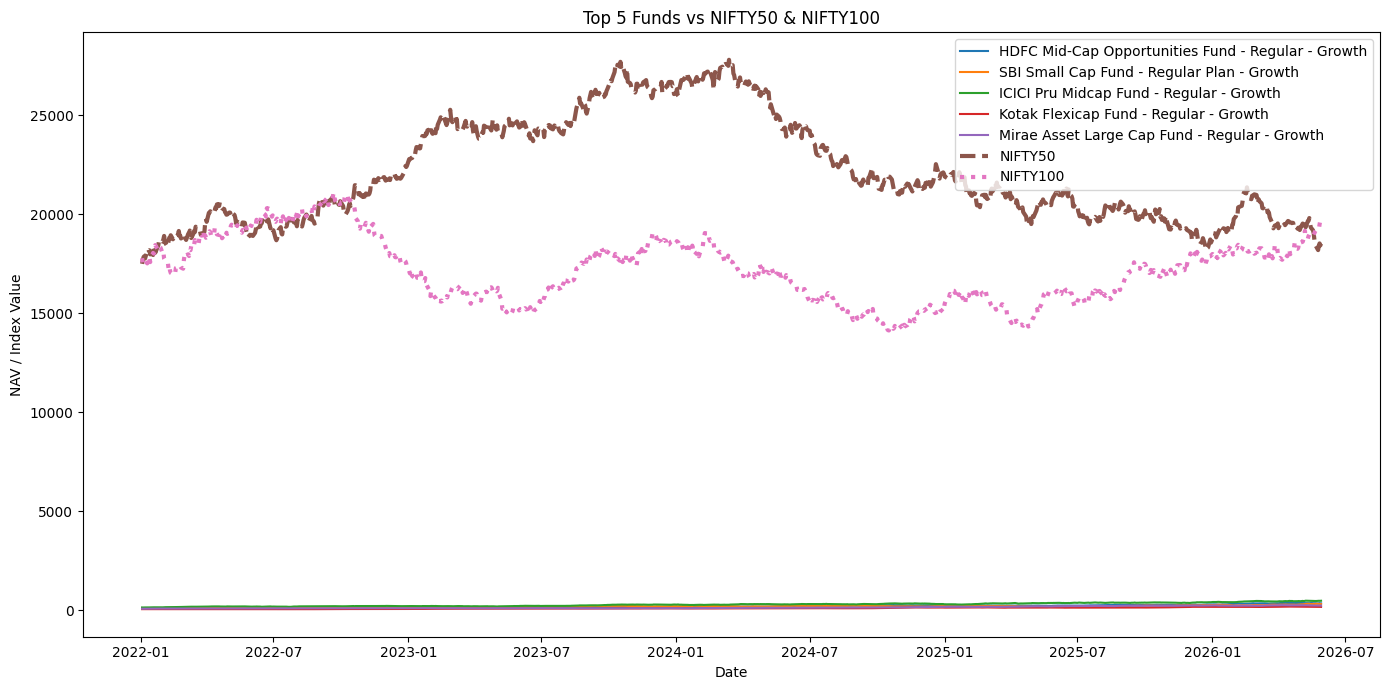

In [76]:
plt.figure(figsize=(14,7))

# Top 5 Funds
for fund in top5_nav["scheme_name"].unique():

    temp = top5_nav[
        top5_nav["scheme_name"]==fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=fund
    )

# NIFTY50
plt.plot(
    nifty50["date"],
    nifty50["close_value"],
    linewidth=3,
    linestyle="--",
    label="NIFTY50"
)

# NIFTY100
plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    linewidth=3,
    linestyle=":",
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")

plt.xlabel("Date")
plt.ylabel("NAV / Index Value")

plt.legend()

plt.tight_layout()

plt.show()

In [77]:
plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [79]:
nifty100.columns.tolist()

['date', 'index_name', 'close_value']

In [80]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(nifty100["date"])

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100 = nifty100.dropna()

nifty100.head()

,date,index_name,close_value,benchmark_return
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351


In [81]:
temp = temp.merge(
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

In [82]:
temp = temp.merge(
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

In [84]:
tracking_error = pd.DataFrame(tracking_error)

tracking_error.head()

""


In [85]:
tracking_error.to_csv(
    "../outputs/tracking_error.csv",
    index=False
)

## Benchmark Comparison

The benchmark comparison illustrates how the top-performing mutual funds tracked against the NIFTY50 and NIFTY100 indices.

Tracking Error measures the consistency of fund returns relative to the benchmark. Lower Tracking Error indicates closer benchmark tracking, while higher values indicate greater active management.